# # Apple Stock Market Analysis

Analysis of Apple (AAPL) historical stock data from 2020 to 2024 using Python.

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Display all columns
pd.set_option("display.max_columns", None)

# Better plot size
plt.rcParams["figure.figsize"] = (12,6)

In [41]:
df = pd.read_csv("data/AAPL.csv")

In [42]:
df.shape

(1260, 6)

In [43]:
df.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
1,Date,NaN,NaN,NaN,NaN,NaN
2,2020-01-02,72.33387756347656,72.39408555090253,71.0911838210517,71.34405442839761,135480400
3,2020-01-03,71.6306381225586,72.38925722098051,71.40666619485818,71.56320547713457,146322800
4,2020-01-06,72.20140075683594,72.23993474282962,70.50353879987532,70.7540060340311,118387200


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1260 entries, 0 to 1259
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Price   1260 non-null   object
 1   Close   1259 non-null   object
 2   High    1259 non-null   object
 3   Low     1259 non-null   object
 4   Open    1259 non-null   object
 5   Volume  1259 non-null   object
dtypes: object(6)
memory usage: 59.2+ KB


In [45]:
df.describe()

,Price,Close,High,Low,Open,Volume
count,1260,1259,1259,1259,1259,1259
unique,1260,1244,1259,1259,1259,1257
top,2024-12-31,88.1353530883789,251.6720594492945,247.84649497663966,250.83739579916153,97918500
freq,1,2,1,1,1,2


In [46]:
df = df.iloc[2:].reset_index(drop=True)

df.rename(columns={"Price": "Date"}, inplace=True)

In [47]:
df["Date"] = pd.to_datetime(df["Date"])

In [48]:
df = df.sort_values("Date").reset_index(drop=True)

In [49]:
numeric_cols = ["Close", "High", "Low", "Open", "Volume"]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col])

In [50]:
df.isnull().sum()

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [51]:
df.duplicated().sum()

np.int64(0)

In [52]:
print("Rows, Columns:", df.shape)

Rows, Columns: (1258, 6)


# EDA

In [53]:
print("Highest Closing Price:", df["Close"].max())

Highest Closing Price: 257.3755798339844


In [54]:
print("Lowest Closing Price:", df["Close"].min())

Lowest Closing Price: 54.16371154785156


In [55]:
print("Average Closing Price:", round(df["Close"].mean(),2))

Average Closing Price: 151.38


In [56]:
print("Highest Trading Volume:", df["Volume"].max())

Highest Trading Volume: 426510000


In [57]:
print("Lowest Trading Volume:", df["Volume"].min())

Lowest Trading Volume: 23234700


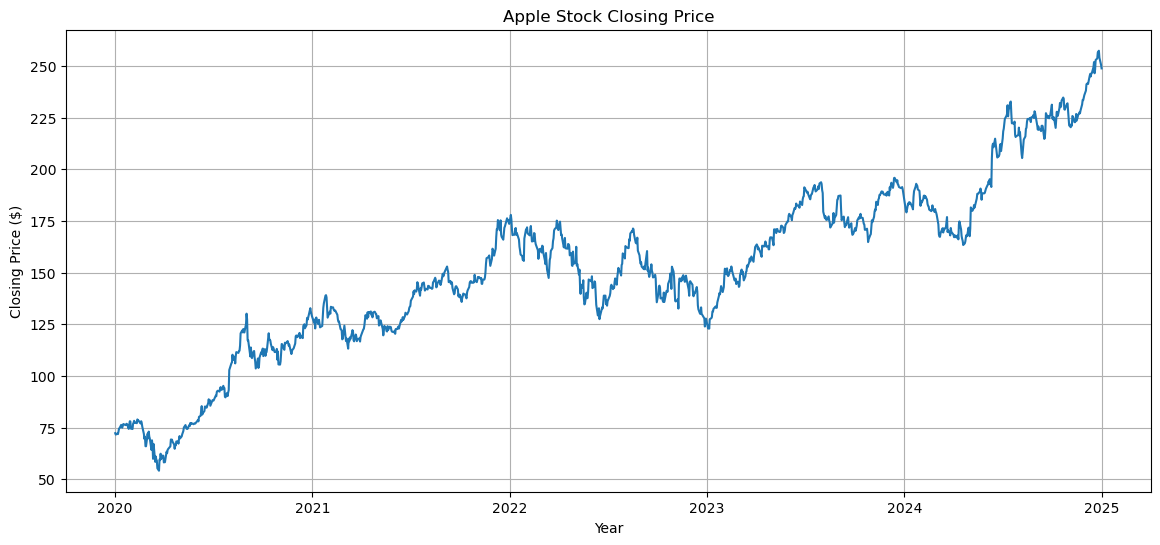

In [58]:
plt.figure(figsize=(14,6))

plt.plot(df["Date"], df["Close"])

plt.title("Apple Stock Closing Price")
plt.xlabel("Year")
plt.ylabel("Closing Price ($)")

plt.grid(True)

plt.show()

The chart clearly shows:

Apple experienced a sharp decline in early 2020 (COVID-19 market crash).
From mid-2020 onward, the stock entered a strong upward trend.
There were noticeable corrections during 2022 and early 2024.
The stock reached its highest price near the end of 2024.
Overall, Apple generated significant long-term growth.

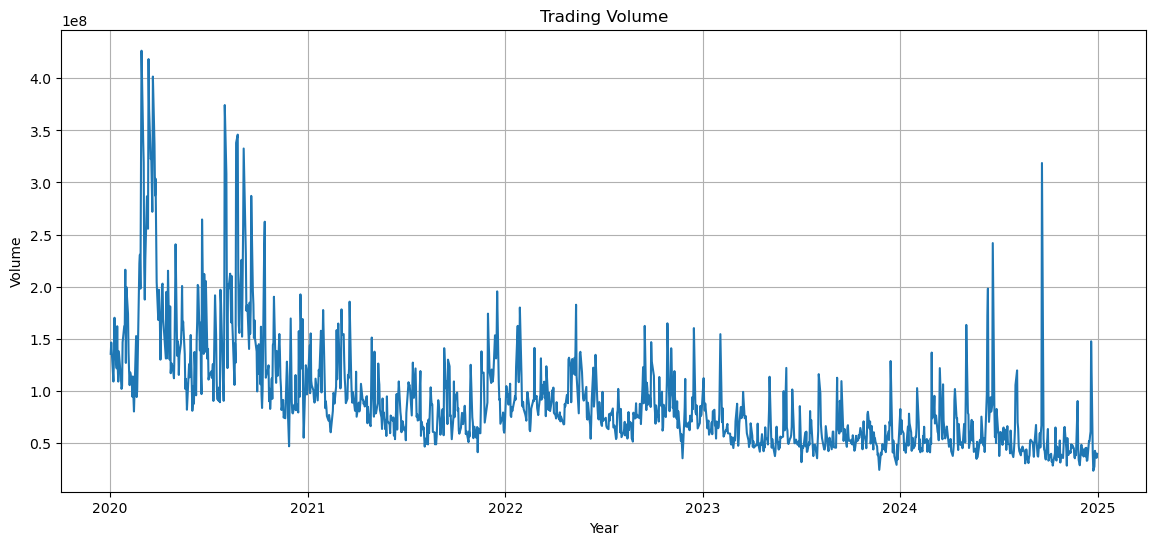

In [59]:
plt.figure(figsize=(14,6))

plt.plot(df["Date"], df["Volume"])

plt.title("Trading Volume")
plt.xlabel("Year")
plt.ylabel("Volume")

plt.grid(True)

plt.show()

Trading volume was highest during early 2020.
Large spikes indicate periods of major market activity or important news.
Average volume gradually decreased after 2021.
Occasional spikes in 2024 suggest increased investor participation around significant events.

#  Return Analysis

In [60]:
df["Daily Return"] = df["Close"].pct_change() * 100

In [61]:
df["MA20"] = df["Close"].rolling(window=20).mean()

In [62]:
df["MA50"] = df["Close"].rolling(window=50).mean()

In [63]:
df["Volatility"] = df["Daily Return"].rolling(window=20).std()

In [64]:
df.head(25)

,Date,Close,High,Low,Open,Volume,Daily Return,MA20,MA50,Volatility
0,2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400,NaN,NaN,NaN,NaN
1,2020-01-03,71.630638,72.389257,71.406666,71.563205,146322800,-0.972213,NaN,NaN,NaN
2,2020-01-06,72.201401,72.239935,70.503539,70.754006,118387200,0.796814,NaN,NaN,NaN
3,2020-01-07,71.861870,72.466353,71.642712,72.211072,108872000,-0.470255,NaN,NaN,NaN
4,2020-01-08,73.017830,73.318870,71.565614,71.565614,132079200,1.608586,NaN,NaN,NaN
5,2020-01-09,74.568779,74.761442,73.742727,73.993187,170108400,2.124069,NaN,NaN,NaN
6,2020-01-10,74.737373,75.300927,74.236446,74.802403,140644800,0.226092,NaN,NaN,NaN
7,2020-01-13,76.334106,76.360602,74.934873,75.052886,121532000,2.136459,NaN,NaN,NaN
8,2020-01-14,75.303345,76.481017,75.180525,76.271494,161954400,-1.350329,NaN,NaN,NaN
9,2020-01-15,74.980621,75.982483,74.549530,75.103448,121923600,-0.428564,NaN,NaN,NaN


# Trend Analysis

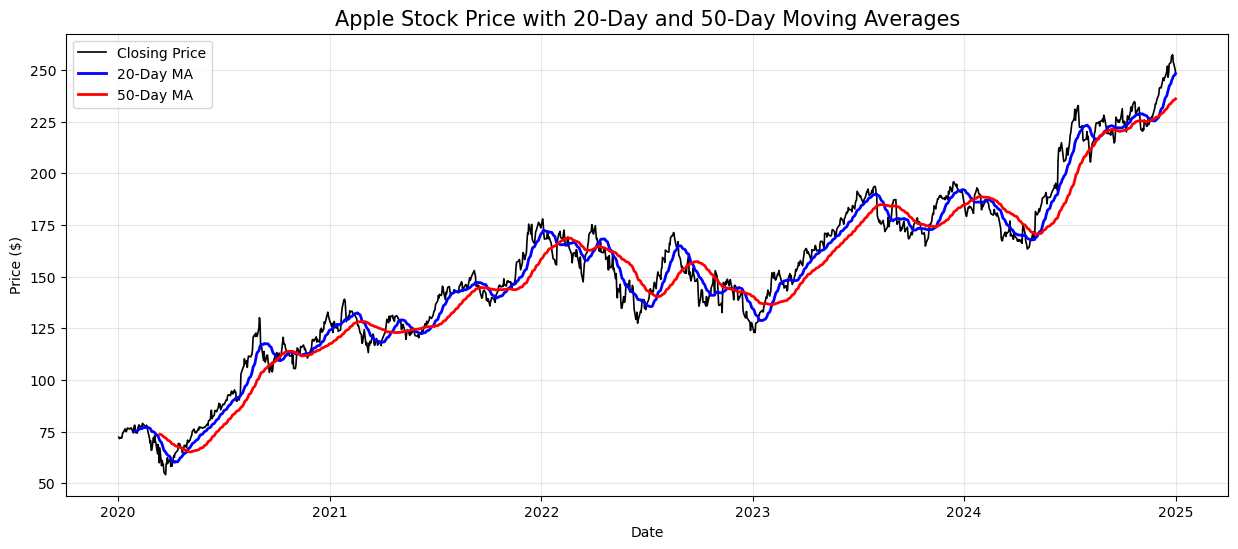

In [65]:
plt.figure(figsize=(15,6))

plt.plot(df["Date"], df["Close"], color="black", linewidth=1.2, label="Closing Price")
plt.plot(df["Date"], df["MA20"], color="blue", linewidth=2, label="20-Day MA")
plt.plot(df["Date"], df["MA50"], color="red", linewidth=2, label="50-Day MA")

plt.title("Apple Stock Price with 20-Day and 50-Day Moving Averages", fontsize=15)
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

The 20-day moving average responds quickly to short-term price changes.
The 50-day moving average captures the longer-term trend.
During late 2024, the 20-day MA remained above the 50-day MA, indicating sustained bullish momentum.
In 2022, the two moving averages crossed several times, reflecting a more volatile and sideways market.

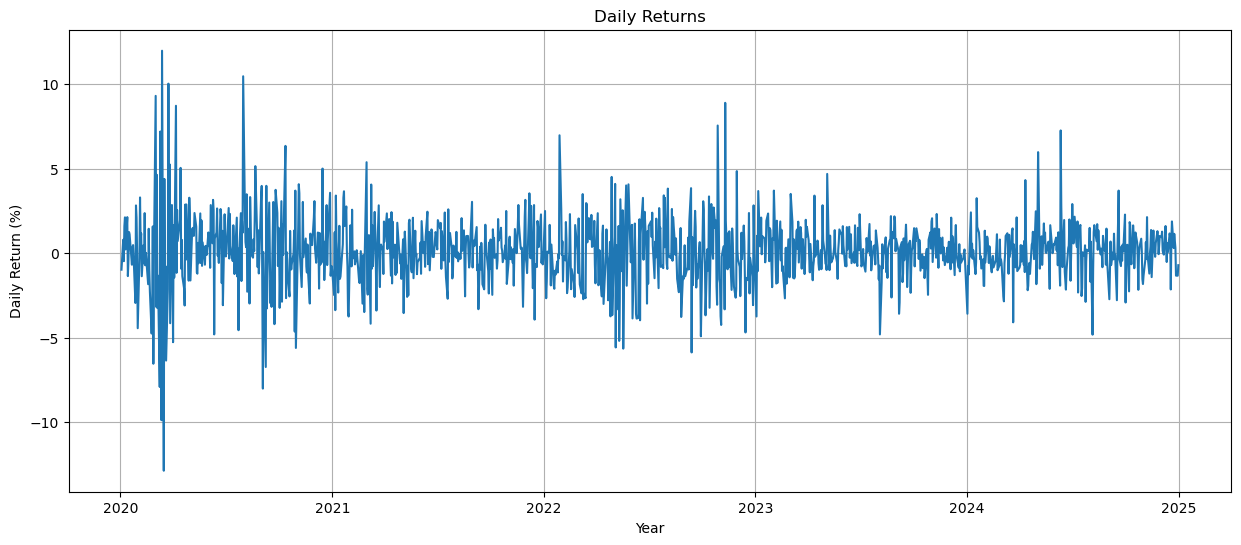

In [66]:
plt.figure(figsize=(15,6))

plt.plot(df["Date"], df["Daily Return"])

plt.title("Daily Returns")

plt.xlabel("Year")

plt.ylabel("Daily Return (%)")

plt.grid(True)

plt.show()

Average daily return is 0.1182%, indicating a positive average return over the period.
The largest gain was approximately 11.98%, while the largest loss was approximately 12.86%.
The largest fluctuations occurred during early 2020, consistent with the market disruption caused by COVID-19.

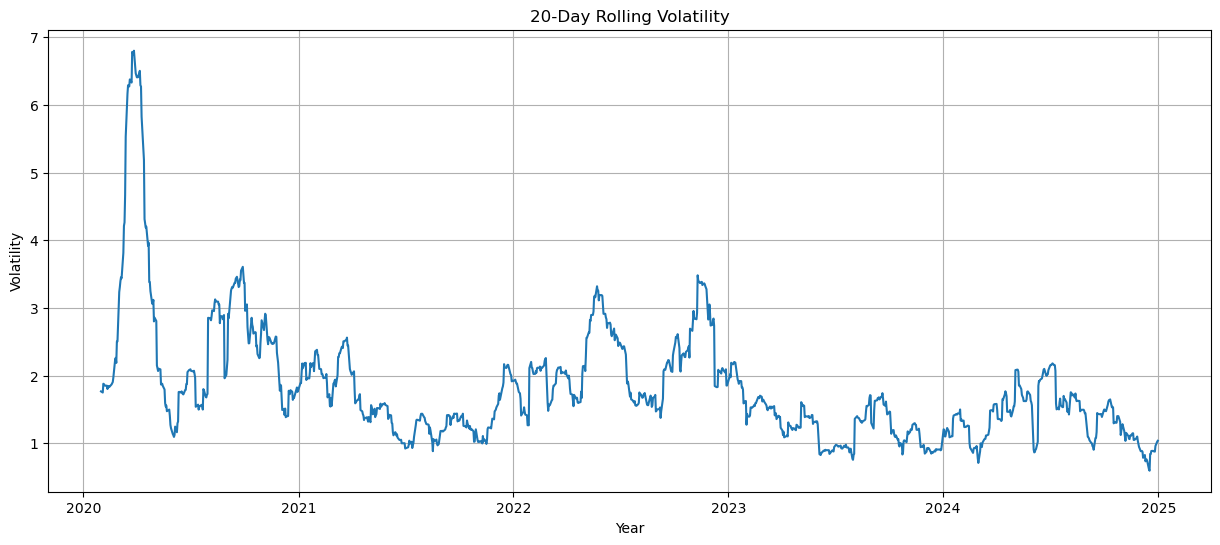

In [67]:
plt.figure(figsize=(15,6))

plt.plot(df["Date"], df["Volatility"])

plt.title("20-Day Rolling Volatility")

plt.xlabel("Year")

plt.ylabel("Volatility")

plt.grid(True)

plt.show()

Volatility was highest during early 2020, indicating increased market uncertainty.
After 2021, volatility generally declined, suggesting more stable price movements.
Temporary increases in volatility correspond to periods of significant price corrections or market events.

# Risk Analysis

In [68]:
print("Average Daily Return (%):", round(df["Daily Return"].mean(),4))
print("Maximum Daily Return (%):", round(df["Daily Return"].max(),4))
print("Minimum Daily Return (%):", round(df["Daily Return"].min(),4))
print("Average Volatility:", round(df["Volatility"].mean(),4))

Average Daily Return (%): 0.1182
Maximum Daily Return (%): 11.9808
Minimum Daily Return (%): -12.8647
Average Volatility: 1.8103


In [69]:
df["Cumulative Return"] = (1 + df["Daily Return"]/100).cumprod()

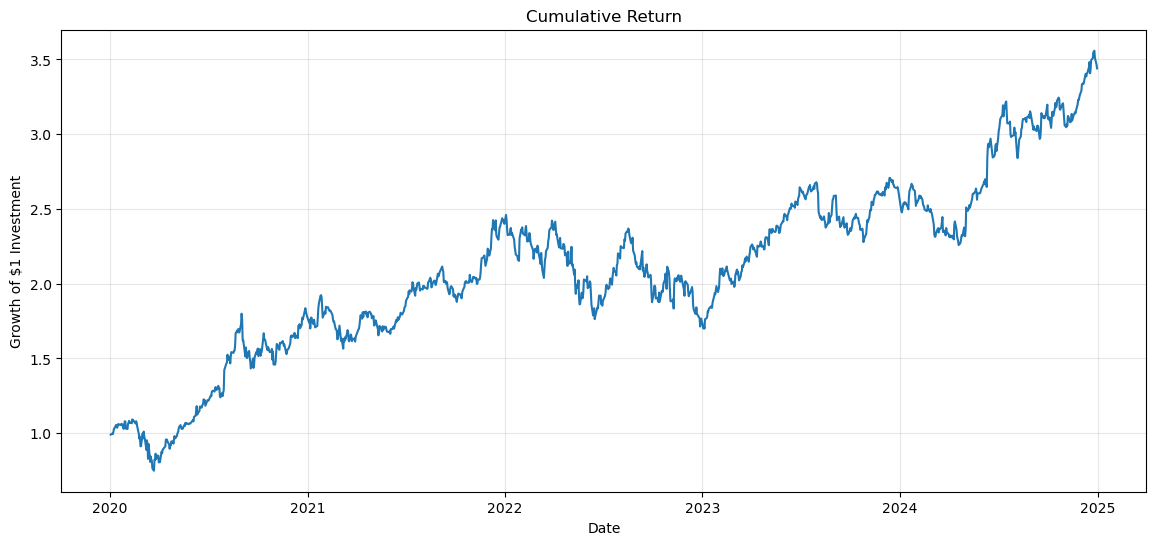

In [70]:
plt.figure(figsize=(14,6))

plt.plot(df["Date"], df["Cumulative Return"])

plt.title("Cumulative Return")

plt.xlabel("Date")

plt.ylabel("Growth of $1 Investment")

plt.grid(alpha=0.3)

plt.show()

# insights

- A hypothetical $1 investment grew to approximately $3.5 by the end of the analysis period.
- The investment experienced several temporary declines during the period, showing that returns were not consistently positive.
- Overall, the stock generated positive long-term performance despite periods of volatility and drawdown.

In [71]:
df["Running Max"] = df["Close"].cummax()

df["Drawdown"] = (df["Close"] - df["Running Max"]) / df["Running Max"]

max_drawdown = df["Drawdown"].min()

print(f"Maximum Drawdown: {max_drawdown:.2%}")

Maximum Drawdown: -31.43%


In [72]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month_name()

In [73]:
monthly = df.groupby("Month")["Daily Return"].mean()

monthly

Month
April        0.152972
August       0.188169
December     0.122387
February    -0.253514
January      0.088306
July         0.448194
June         0.329235
March        0.099149
May          0.152001
November     0.322502
October      0.078500
September   -0.348426
Name: Daily Return, dtype: float64

In [74]:
order = ["January","February","March","April","May","June",
         "July","August","September","October","November","December"]

monthly = monthly.reindex(order)

# Performance Analysis

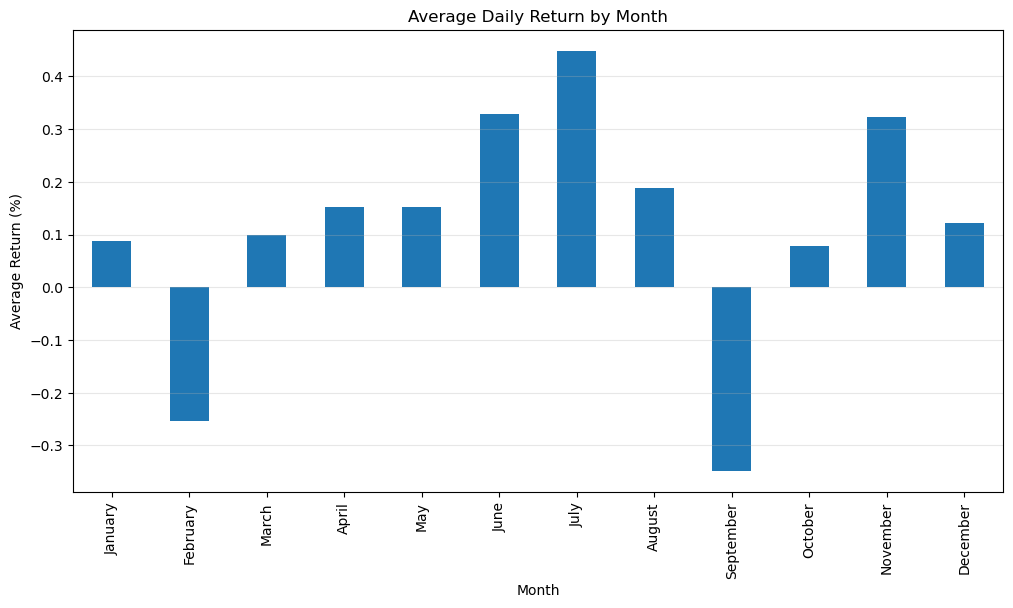

In [75]:
plt.figure(figsize=(12,6))

monthly.plot(kind="bar")

plt.title("Average Daily Return by Month")

plt.ylabel("Average Return (%)")

plt.grid(axis="y", alpha=0.3)

plt.show()

# insights

- Average daily returns varied across different months.
- July recorded the highest average daily return among the months analyzed.
- September recorded the lowest average daily return.
- February also showed a negative average daily return, while most other months had positive average daily returns.
- The analysis shows that daily return patterns varied across calendar months.

In [76]:
annual_return = (
    df.groupby("Year")
    .apply(
        lambda x: (
            (x["Close"].iloc[-1] / x["Close"].iloc[0]) - 1
        ) * 100
    )
)

annual_return

C:\Users\VinArs\AppData\Local\Temp\ipykernel_14652\1905209524.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


Year
2020    78.239914
2021    38.060958
2022   -28.199488
2023    54.798240
2024    35.556364
dtype: float64

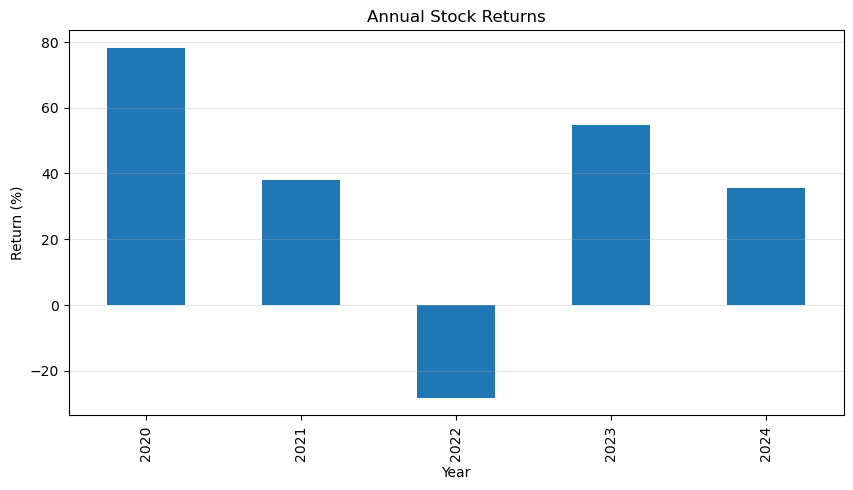

In [77]:
plt.figure(figsize=(10, 5))

annual_return.plot(kind="bar")

plt.title("Annual Stock Returns")
plt.xlabel("Year")
plt.ylabel("Return (%)")

plt.grid(axis="y", alpha=0.3)

plt.show()

# insights

- Apple generated positive annual returns in 2020, 2021, 2023, and 2024.
- 2022 was the only year in the analysis period with a negative annual return.
- The strongest annual performance occurred in 2020.
- The results show that long-term performance was positive despite a significant negative-return year in 2022.

# Key Findings

- Apple showed an overall positive long-term performance during the 2020–2024 analysis period.
- A hypothetical $1 investment grew to approximately $3.5 by the end of the period.
- Annual returns were positive in four of the five years analyzed, while 2022 recorded a negative annual return.
- Average daily returns varied across months, with July showing the highest average and September showing the lowest.
- The analysis demonstrates that positive long-term performance can occur despite short-term fluctuations and periods of negative returns.